# Introduction and Plan

## 1.1. Problem Definition

With this project we hope to address the binary image classification problem of distinguishing between dogs and cats. The task is to build and compare multiple deep learning models on a real-world dataset, with the goal of:

- Achieving high accuracy on unseen test images
- Understanding the pros and cons of transfer learning
- Explaining model predictions using Grad-CAM explainability

**Input:** RGB images of dogs and cats
**Output:** Predicted class label: {cat, dog}
**Number of Classes:** 2

## 1.2. Dataset Choice and Justification
**The Dataset:** [Dog and Cat Classification Dataset](https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset/code)

**Dataset Properties:**
- **Total images:** 24,998, split into 12,499 Cat images abd 12,499 Dog images
- **Image format:** RGB JPEG/PNG

**Why this dataset?**
- Natural, real-world images with diverse lighting conditions and poses
- Balanced classes eliminate need for class weighting
- Sufficient data size for meaningful transfer learning comparison
- Well-studied benchmark for image classification
- Practical relevance: pet classification is a real-world application

## 1.3. Evaluation Metrics and Protocol

## 1.4 High-level Plan


# Data exploration and Preprocessing

### Imports and Global Setup

In [1]:
import os
import time
import copy
import shutil
import random
from cmath import phase

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# random seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")


2025-12-10 20:33:28.633487: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Using device: cuda


### Configuration

In [2]:
RAW_DATA_DIR = 'data/PetImages'
PROCESSED_DATA_DIR = 'data/processed'
SAVED_MODELS_DIR = 'saved_models/baseline_resnet50'
LOG_DIR = 'logs/baseline_resnet50'
CHECKPOINT_DIR = 'checkpoints'

os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)
os.makedirs(SAVED_MODELS_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

IMG_SIZE = 224 #this is for ResNet50 specifically, because it expects 224x224
NUM_CLASSES = 2
CLASS_NAMES = ['cat', 'dog']

BATCH_SIZE = 32
NUM_WORKERS = 4 #RADU: you may need to change this/not use it for your laptop
NUM_EPOCHS = 10
LEARNING_RATE = 0.001 #This is a learning rate suitable for ResNet50, because I'm freezing the backbone of the model and only adapting the final classifier, so a larger learning rate would make drastic changes that destroy the pretrained knowledge/weights

### Data Splitting

RADU: Two things to consider:
- When it comes to the splitting of the data I have decided to use ImageFolder, which in the end copies files into directories. *This is the only approach that works with ImageFolder*. However, it leads to double disk usage, on my laptop and probably on Vesela's, this is not a problem. On yours though, idk if it'll slow you down. Run the splitting and if it's really slow, update me so I can change is to another method.

- In the brightness analysis loop in "eda", I convert every pixel into a standard python list, which for high-resolution images it eats up massive amounts of RAM and is very slow. Once again, on my laptop(and probably Vesela's), it's not a problem, but it may be for you, so update me if I need to change that as well

In [3]:
def create_train_val_test_split(raw_data_dir, output_dir, train_ratio, val_ratio, test_ratio, seed):
    os.makedirs(output_dir, exist_ok=True)
    for class_name in sorted(os.listdir(raw_data_dir)):
        class_path = os.path.join(raw_data_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [f for f in os.listdir(class_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        #First split into train and temp(val + test), not entirely sure if it should be like that, RADU check
        train, temp = train_test_split(images, train_size=train_ratio, random_state=seed, shuffle=True)

        #This splits val and test from temp, once again, unsure how correct this is LMAO
        val_size_of_temp = val_ratio / (val_ratio + test_ratio)
        val, test = train_test_split(temp, train_size=val_size_of_temp, random_state=seed, shuffle=True)

        for split, file_list in [('train', train), ('val', val),('test', test)]:
            split_dir = os.path.join(output_dir, split, class_name)
            os.makedirs(split_dir, exist_ok=True)

            for img_file in tqdm(file_list, desc=f'Copying {split}/{class_name}'):
                src = os.path.join(class_path, img_file)
                dst = os.path.join(split_dir, img_file)
                if not os.path.exists(dst):
                    shutil.copy2(src, dst)

create_train_val_test_split(raw_data_dir=RAW_DATA_DIR,
                            output_dir=PROCESSED_DATA_DIR,
                            train_ratio=0.7, val_ratio=0.15, test_ratio=0.15,
                            seed=SEED)

Copying test/Dog: 100%|██████████| 1875/1875 [00:00<00:00, 110557.97it/s]


### Exploratory Data Analysis

We perform EDA on the training dataset to both understand what we're working with and decide on preprocessing needs. There was a list of questions we had that needed to be answered before we define the transforms, including:

- What are the image dimensions? -> So we can decide the resize target
- What is the class distribution? -> As it may affect loss weighting
- What is the color space? -> So we can decide if we need conversion
- Are there corrupted images? -> As we need to handle them before preprocessing
- What is the brightness/contrast range? -> So we can decide the augmentation amounts


Class Distribution:
  Cats: 8749 (50.0%)
  Dogs: 8749 (50.0%)

Image Dimensions:
  Width:  141 - 500 pixels (mean: 409)
Height: 162 - 500 pixels (mean: 373)


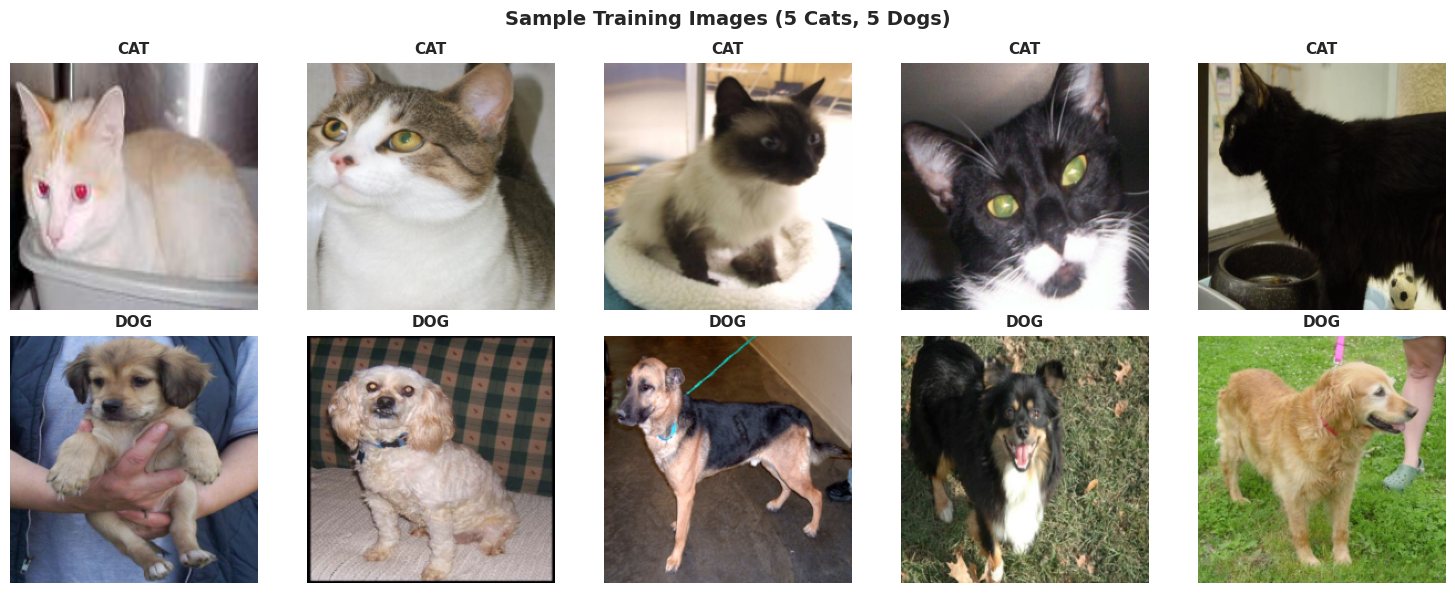


COLOR SPACE ANALYSIS
Color modes found: {'RGB': 200}
All images are already RGB

CORRUPTED IMAGE CHECK


/home/aleks/PycharmProjects/dl-cats-dogs/.venv/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


No corrupted images found

BRIGHTNESS AND CONTRAST ANALYSIS
  Pixel value range: 0 - 255
  Mean brightness: 114.8 / 255
  Std deviation: 65.0


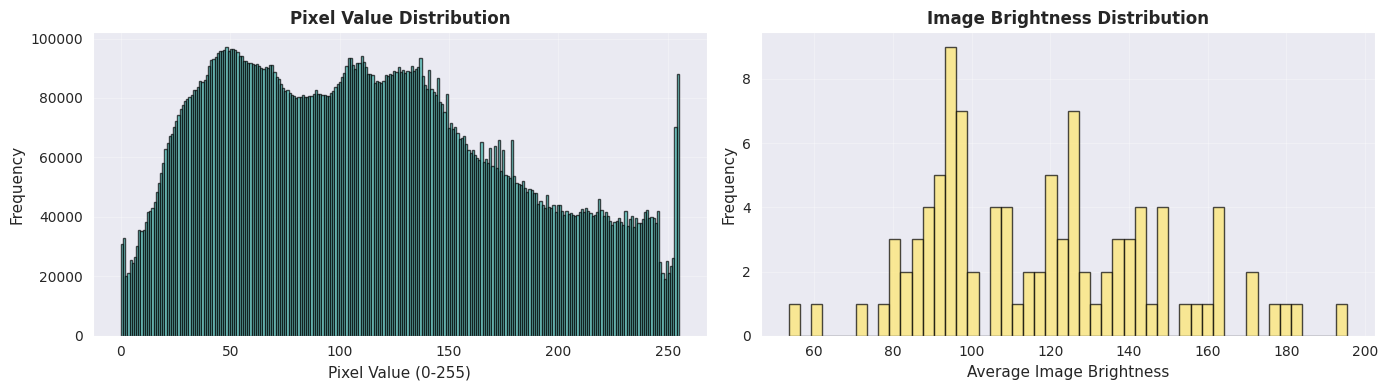

Brightness range across images: 53.5 - 195.4
Justification for color jitter: Images have varied brightness (std=29.0)
Recommended jitter range: brightness ±15%, contrast ±20%


In [4]:
def eda(data_dir):
    train_cat = len(os.listdir(os.path.join(data_dir, 'train', 'Cat')))
    train_dog = len(os.listdir(os.path.join(data_dir, 'train', 'Dog')))

    print(f"\nClass Distribution:")
    print(f"  Cats: {train_cat} ({100*train_cat/(train_cat+train_dog):.1f}%)")
    print(f"  Dogs: {train_dog} ({100*train_dog/(train_cat+train_dog):.1f}%)")

    widths, heights = [], []

    for img_file in os.listdir(os.path.join(data_dir, 'train', 'Cat'))[:50]:
        try:
            img = Image.open(os.path.join(data_dir, 'train', 'Cat', img_file))
            w, h = img.size
            widths.append(w)
            heights.append(h)
        except:
            pass

    for img_file in os.listdir(os.path.join(data_dir, 'train', 'Dog'))[:50]:
        try:
            img = Image.open(os.path.join(data_dir, 'train', 'Dog', img_file))
            w, h = img.size
            widths.append(w)
            heights.append(h)
        except:
            pass

    print(f"\nImage Dimensions:")
    print(f"  Width:  {min(widths)} - {max(widths)} pixels (mean: {np.mean(widths):.0f})")
    print(f"Height: {min(heights)} - {max(heights)} pixels (mean: {np.mean(heights):.0f})")

    #Used ai for visualizing sample images:D
    train_dataset = ImageFolder(root=os.path.join(data_dir, 'train'),
        transform=transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor()
        ])
    )

    cat_class_indx = train_dataset.class_to_idx['Cat']
    dog_class_indx = train_dataset.class_to_idx['Dog']

    cat_indices = [i for i, (_, label) in enumerate(train_dataset.imgs) if label == cat_class_indx]
    dog_indices = [i for i, (_, label) in enumerate(train_dataset.imgs) if label == dog_class_indx]

    np.random.seed(42)
    num_samples_per_class = 5
    cat_samples = np.random.choice(cat_indices, size=num_samples_per_class, replace=False)
    dog_samples = np.random.choice(dog_indices, size=num_samples_per_class, replace=False)

    fig, axes = plt.subplots(2, num_samples_per_class, figsize=(15, 6))
    axes = axes.flatten()

    all_samples = list(cat_samples) + list(dog_samples)

    for plot_idx, data_idx in enumerate(all_samples):
        data_idx = int(data_idx)
        img, label = train_dataset[data_idx]
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)

        class_name = train_dataset.classes[label]
        axes[plot_idx].imshow(img)
        axes[plot_idx].set_title(f'{class_name.upper()}', fontsize=11, fontweight='bold')
        axes[plot_idx].axis('off')

    plt.suptitle('Sample Training Images (5 Cats, 5 Dogs)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    #Color space analysis
    print("\nCOLOR SPACE ANALYSIS")
    color_modes = {}

    for img_file in os.listdir(os.path.join(data_dir, 'train', 'Cat'))[:100]:
        try:
            img = Image.open(os.path.join(data_dir, 'train', 'Cat', img_file))
            mode = img.mode  # RGB, RGBA, L, etc.
            color_modes[mode] = color_modes.get(mode, 0) + 1
        except:
            pass

    for img_file in os.listdir(os.path.join(data_dir, 'train', 'Dog'))[:100]:
        try:
            img = Image.open(os.path.join(data_dir, 'train', 'Dog', img_file))
            mode = img.mode
            color_modes[mode] = color_modes.get(mode, 0) + 1
        except:
            pass

    print(f"Color modes found: {color_modes}")

    # Count images that are NOT RGB
    non_rgb_count = sum(count for mode, count in color_modes.items() if mode != 'RGB')
    if non_rgb_count > 0:
        print(f"{non_rgb_count} images are not RGB - will be converted during preprocessing")
    else:
        print(f"All images are already RGB")


    #Corrupted Image Check- Im gonna be completely honest, idk if dealing with corrupted images should happen before any data splitting or after the data splitting, before preprocessing, but idc, here's the stats gang, i hate eda, RELEASE ME

    print("\nCORRUPTED IMAGE CHECK")
    corrupted_count = 0

    for img_file in os.listdir(os.path.join(data_dir, 'train', 'Cat')):
        try:
            img = Image.open(os.path.join(data_dir, 'train', 'Cat', img_file))
            img.verify()
        except:
            corrupted_count += 1

    for img_file in os.listdir(os.path.join(data_dir, 'train', 'Dog')):
        try:
            img = Image.open(os.path.join(data_dir, 'train', 'Dog', img_file))
            img.verify()
        except:
            corrupted_count += 1

    if corrupted_count == 0:
        print(f"No corrupted images found")
    else:
        print(f"{corrupted_count} corrupted images detected")

    #Brightness and Contrast Range
    print("\nBRIGHTNESS AND CONTRAST ANALYSIS")

    pixel_values = []

    # Sample pixel values from a few images. If the values are not rgb, turn them into rgb
    for img_file in os.listdir(os.path.join(data_dir, 'train', 'Cat'))[:20]:
        try:
            img = Image.open(os.path.join(data_dir, 'train', 'Cat', img_file))
            if img.mode != 'RGB':
                img = img.convert('RGB')

            img_array = np.array(img)
            pixel_values.extend(img_array.flatten().tolist())
        except:
            pass

    for img_file in os.listdir(os.path.join(data_dir, 'train', 'Dog'))[:20]:
        try:
            img = Image.open(os.path.join(data_dir, 'train', 'Dog', img_file))
            if img.mode != 'RGB':
                img = img.convert('RGB')

            img_array = np.array(img)
            pixel_values.extend(img_array.flatten().tolist())
        except:
            pass

    pixel_values = np.array(pixel_values)

    print(f"  Pixel value range: {pixel_values.min():.0f} - {pixel_values.max():.0f}")
    print(f"  Mean brightness: {pixel_values.mean():.1f} / 255")
    print(f"  Std deviation: {pixel_values.std():.1f}")

    # Used ai for visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].hist(pixel_values, bins=256, alpha=0.7, color='#4ECDC4', edgecolor='black')
    axes[0].set_xlabel('Pixel Value (0-255)', fontsize=11)
    axes[0].set_ylabel('Frequency', fontsize=11)
    axes[0].set_title('Pixel Value Distribution', fontsize=12, fontweight='bold')
    axes[0].grid(alpha=0.3)

    # Brightness per image
    brightness_per_image = []

    for img_file in os.listdir(os.path.join(data_dir, 'train', 'Cat'))[:50]:
        try:
            img = Image.open(os.path.join(data_dir, 'train', 'Cat', img_file))
            if img.mode != 'RGB':
                img = img.convert('RGB')
            img_array = np.array(img)
            brightness = img_array.mean()
            brightness_per_image.append(brightness)
        except:
            pass

    for img_file in os.listdir(os.path.join(data_dir, 'train', 'Dog'))[:50]:
        try:
            img = Image.open(os.path.join(data_dir, 'train', 'Dog', img_file))
            if img.mode != 'RGB':
                img = img.convert('RGB')
            img_array = np.array(img)
            brightness = img_array.mean()
            brightness_per_image.append(brightness)
        except:
            pass

    #Used ai for visualizing
    axes[1].hist(brightness_per_image, bins=50, alpha=0.7, color='#FFE66D', edgecolor='black')
    axes[1].set_xlabel('Average Image Brightness', fontsize=11)
    axes[1].set_ylabel('Frequency', fontsize=11)
    axes[1].set_title('Image Brightness Distribution', fontsize=12, fontweight='bold')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Brightness range across images: {min(brightness_per_image):.1f} - {max(brightness_per_image):.1f}")
    print(f"Justification for color jitter: Images have varied brightness (std={np.std(brightness_per_image):.1f})")
    print(f"Recommended jitter range: brightness ±{int(20 * max(brightness_per_image) / 255)}%, contrast ±20%")

 #Ran only on train
eda(PROCESSED_DATA_DIR)

## EDA Findings and Justifications

1. Class Distribution:
- There is no class imbalance, so no need for weighted loss or sampling strategies.

2. Image Dimensions
- Images vary widely in size, which justifies a fixed resizing to 224x224, as we need a uniform input size for batch processing.

3. Color Space
- All images are already in RGB format, so no need for color space conversion.

4. Brightness and Contrast
- The left graph (Pixel Value Distribution) shows all individual pixel values across the dataset and we can see that there is a broad, continuous distribution. What this means is that the images have a good dynamic range.

- The right graph (Average Image Brightness) has multiple peaks, as well as high
variance-from ~60 to ~200, which leads us to the conclusion that the dataset contains images from vastly different lightning conditions. It also strongly justifies the use of color jitter augmentation for better generalization.



### Data Pipeline - Tranforms and Dataloaders

Ok so, the training transforms include augmentation, i.e., random flips, rotations, etc., while the validation and test transforms only include the necessary preprocessing.
All transforms normalize using ImageNet mean/std, not only because the baseline ResNet50 is pretrained on ImageNet, but also because we need to make a fair comparison between it and the scratch cnn. This also returns a torchvision.transforms.Compose object

In [5]:
def get_transforms(augment: bool = True):
    if augment:
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=10),
            transforms.ColorJitter(
                brightness=0.15,
                contrast=0.2,
                saturation=0.2
            ),
            transforms.RandomAffine(
                degrees=0,
                translate=(0.1,0.1)
            ),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    else:
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

get_dataloaders creates and returns DataLoaders for train, validation and test. It's REUSABLE so you two can call this function and ensure you use the exact same data preprocessing and splits. Something important for RADU and Vesela, for the num_worker threads, you may need to experiment with the number, because this is the number of worker threads for data loading and if it's too big, it'll fuck up your laptop.No problem on my linux system with GPU, but could be a problem for a Linux system without GPU and a Windows, for some reason lmao. The function returns a Tuple of (train_loader, val_loader, test_loader)

In [6]:
def get_dataloaders(data_dir, batch_size, num_workers):
    train_dataset = ImageFolder(
        root=os.path.join(data_dir, 'train'),
        transform=get_transforms(augment=True)
    )

    test_dataset = ImageFolder(
        root=os.path.join(data_dir, 'test'),
        transform=get_transforms(augment=False)
    )

    val_dataset = ImageFolder(
        root=os.path.join(data_dir, 'val'),
        transform=get_transforms(augment=False)
    )

    #Shuffling only the training data each epoch, not the validation and test data
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        drop_last=False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        drop_last=False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        drop_last=False
    )

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = get_dataloaders(
    data_dir=PROCESSED_DATA_DIR,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS
)

# Baseline model

The model we have chosen is **ResNet50**. It is an industry-standard "workhorse" and offers an excellent balance between accuracy and computational efficiency, while being "deep enough" to capture complex features.

Since we are training a relatively small dataset compared to ImageNet(the dataset that ResNet50 was trained on), we have decided to freeze the pre-trained convolutional layers and only replace and train the fully connected layer.

## Defining the Model and Training Engine

In [9]:
def get_resnet(num_classes, device):
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

    #this freezes the convolutional layers
    for param in model.parameters():
        param.requires_grad = False

    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)

    return model.to(device)

def train_model(model, train_dl, val_dl, criterion, optimizer, experiment_name, num_epochs, device):
    writer = SummaryWriter(log_dir=os.path.join('logs', experiment_name))

    checkpoint_dir = os.path.join('checkpoints', experiment_name)
    os.makedirs(checkpoint_dir, exist_ok=True)

    dataloaders = {'train': train_dl, 'val': val_dl}
    dataset_sizes = {'train': len(train_dl.dataset), 'val': len(val_dl.dataset)}

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]

            writer.add_scalar(f'Loss/{phase}', epoch_loss, epoch)
            writer.add_scalar(f'Accuracy/{phase}', epoch_acc, epoch)

           #saves the best model
            if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

                    save_path = os.path.join(checkpoint_dir, 'best_model.pt')
                    torch.save(model.state_dict(), save_path)

    writer.close()

    # Returns the model with best weights loaded
    model.load_state_dict(best_model_wts)
    return model

This runs the training loop 3 times with different learning rates.

In [10]:
learning_rates = [0.0001, 0.001, 0.01]

criterion = nn.CrossEntropyLoss()

trained_models = {}

for lr in learning_rates:
    exp_name = f"ResNet50_Frozen_LR_{lr}"

    model = get_resnet(num_classes=NUM_CLASSES, device=DEVICE)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    best_model = train_model(
        model=model,
        train_dl=train_loader,
        val_dl=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        experiment_name=exp_name,
        num_epochs=NUM_EPOCHS,
        device=DEVICE
    )

    trained_models[lr] = best_model